In [1]:
from pylab import *

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.4
Plasticnet version  0.1.12
macOS-15.3.2-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
mu_c=0
sigma_c=0
mu_r=0
sigma_r=0



base_sim_dir=f"sims-2025-03-13 mu {mu_c} sigma {sigma_c}"
if not os.path.exists(base_sim_dir):
    os.mkdir(base_sim_dir)
print(base_sim_dir)

sims-2025-03-13 mu 0 sigma 0


In [4]:
number_of_neurons=20
eta=1e-6
number_of_processes=8


In [74]:
def get_responses(t,w,number_of_channels,rf_diameter,theta,k_mat):
    import numpy
    # weights.shape must be = (501, 3, 338)  t, neurons, inputs
    
    numang=len(theta)
    num_k=len(k_mat)
    L=len(t)
    num_neurons=w.shape[1]
    
    responses=numpy.zeros((num_k,numang,number_of_channels,num_neurons,L))

    rf_area=rf_diameter*rf_diameter
    rf_radius=rf_diameter//2
    
    for ti in range(L):
        for ni in range(num_neurons):
            for ch in range(number_of_channels):
                for ki,k in enumerate(k_mat):
                    for ai,th in enumerate(theta):
                        a=3.14159265-th/180.0*3.14159265
                        kx=k*cos(a)
                        ky=k*sin(a)

                        cs=0.0
                        cc=0.0
                        wi=0
                        for i in range(rf_diameter):
                            for j in range(rf_diameter):

                                ds=sin(kx*(i-rf_radius)+ ky*(j-rf_radius))
                                dc=cos(kx*(i-rf_radius)+ ky*(j-rf_radius))

                                w1=w[ti,ni,wi+rf_area*ch]
                                    
                                cs+=w1*ds # response to sin/cos grating input
                                cc+=w1*dc

                                phi=atan2(cc,cs)  # phase to give max response

                                wi+=1

                        c=cs*cos(phi)+cc*sin(phi)     # max response

                        responses[ki,ai,ch,ni,ti]=c

                print(k,th,a,kx,ky)
                raise ValueError
    return responses


In [36]:
k_mat=linspace(1,20,40)/19.0*pi

Text(0.5, 1.0, '0.16534698176788384,0.0625\n3.306939635357677,1.25')

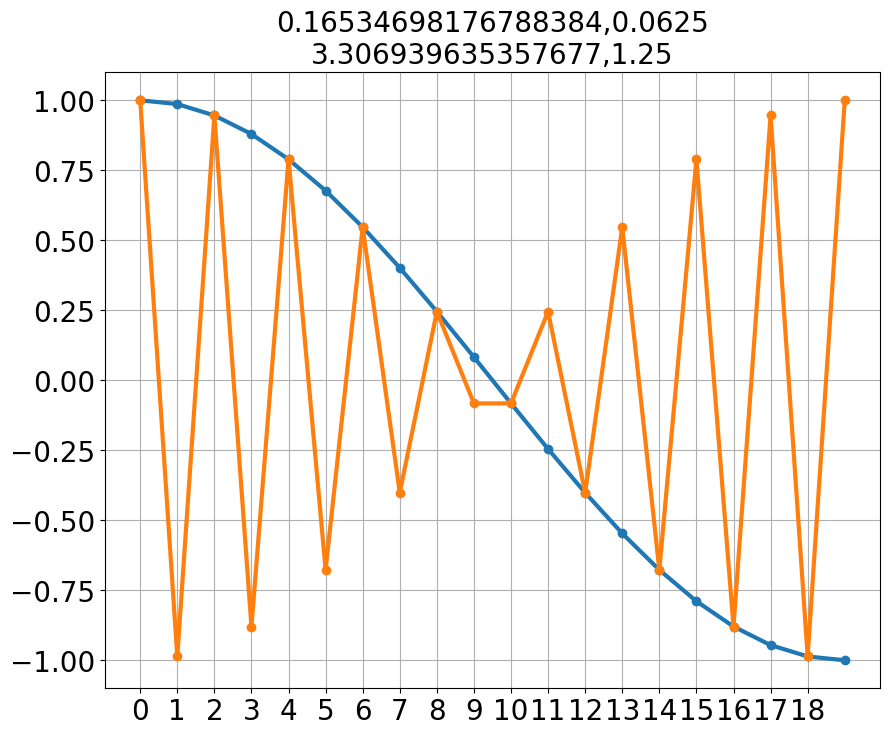

In [38]:
x=linspace(0,19,20)

S=""

k=k_mat[0]
cycles_per_pixel=k/2/pi
deg_per_pixel=8/19
cycles_per_degree=cycles_per_pixel/deg_per_pixel
y=cos(k*x)
plot(x,y,'-o')
gca().set_xticks(arange(19))

S=f"{k},{cycles_per_degree}"
k=k_mat[-1]
cycles_per_pixel=k/2/pi
deg_per_pixel=8/19
cycles_per_degree=cycles_per_pixel/deg_per_pixel
y=cos(k*x)
plot(x,y,'-o')
gca().set_xticks(arange(19))
S+=f"\n{k},{cycles_per_degree}"
title(S)

In [6]:
blur_mat=[0,2,4,6,8,10,12]
open_eye_noise_mat=[0,.1,.2,.3,.4,.5]
mu_c_mat=[0,7,13,21]

sigma_c=0


all_params=[]
for m,mu_c in enumerate(mu_c_mat):
    for b,blur in enumerate(blur_mat):
        for n,noise in enumerate(open_eye_noise_mat):
            sfname=base_sim_dir+f'/deficit {number_of_neurons} neurons noise {noise:.1f} blur {blur:0.1f} mu_c {mu_c:0.1f}.asdf'

            p=Struct()
            p.eta=eta
            p.number_of_neurons=number_of_neurons
            p.sfname=sfname

            p.noise=noise
            p.blur=blur
            p.mu_c=mu_c
            p.sigma_c=sigma_c

            all_params+=[p]

all_params=to_named_tuple(all_params)  


In [7]:
RR={}
for params in tqdm(all_params):
    RR[params.sfname]=Results(params.sfname)

100%|█████████████████████████████████████████| 168/168 [01:01<00:00,  2.72it/s]


In [8]:
subResults={}
for params in tqdm(all_params):
    sfname=params.sfname
    R=RR[sfname]
    
    subR=Struct()
    subR.t=R.t/day
    t=subR.t
    
    subR.y=R.y
    subR.θ=R.θ

    #idx1,idx2=[_[1] for _ in R.sequence_index]
    
    subR.ODI=R.ODI
    subR.ORI=R.ORI
    subR.theta_mat=R.theta_mat
    subR.k_mat=R.k_mat
    subR.SF_Var=R.SF_Var
    subR.max_SF=R.max_SF
    subR.sfname=params.sfname
    subR.params=params
    subR.sequence_index=R.sequence_index
    subR.idx=[0]+[_[-1] for _ in R.sequence_index]
    subR.W=R.W[subR.idx,::]
    #subR.recovery_rate=(R.ODI[idx2,:]-R.ODI[idx1,:])/(t[idx2]-t[idx1])
    #subR.SF_Var_recovery_rate=(R.SF_Var[idx2,:]-R.SF_Var[idx1,:])/(t[idx2]-t[idx1])
    #subR.ODI2=R.ODI[idx2,:]
    #subR.ODI1=R.ODI[idx1,:]
    
    subResults[params.sfname]=subR

100%|████████████████████████████████████████| 168/168 [00:01<00:00, 129.62it/s]


In [9]:
fname='sims-2025-03-13 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0.asdf'
subR=subResults[fname]


In [10]:
subR.W.shape

(2, 20, 722)

In [267]:
def get_responses(t,w,number_of_channels,rf_diameter,theta,k_mat):
    import numpy
    # weights.shape must be = (501, 3, 338)  t, neurons, inputs
    
    numang=len(theta)
    num_k=len(k_mat)
    L=len(t)
    num_neurons=w.shape[1]
    
    responses=numpy.zeros((num_k,numang,number_of_channels,num_neurons,L))

    rf_area=rf_diameter*rf_diameter
    rf_radius=rf_diameter//2

    sin_vals=zeros((rf_diameter,rf_diameter))
    cos_vals=zeros((rf_diameter,rf_diameter))
    
    for ti in tqdm(range(L)):
        for ni in range(num_neurons):
            for ch in range(number_of_channels):
                for ki,k in enumerate(k_mat):
                    for ai,th in enumerate(theta):
                        a=3.14159265-th/180.0*3.14159265
                        kx=k*cos(a)
                        ky=k*sin(a)

                        cs=0.0
                        cc=0.0
                        wi=0
                        for i in range(rf_diameter):
                            for j in range(rf_diameter):

                                ds=sin(kx*(i-rf_radius)+ ky*(j-rf_radius))
                                dc=cos(kx*(i-rf_radius)+ ky*(j-rf_radius))

                                sin_vals[i,j]=ds
                                cos_vals[i,j]=dc
                                w1=w[ti,ni,wi+rf_area*ch]
                                    
                                cs+=w1*ds # response to sin/cos grating input
                                cc+=w1*dc

                                # if wi<30:
                                #     print(f"{wi},{i},{j},w1 {w1:.6f},ds {ds:.6f},dc {dc:.6f}")
                                
                                wi+=1

                        phi=atan2(cc,cs)  # phase to give max response
                        c=cs*cos(phi)+cc*sin(phi)     # max response

                        responses[ki,ai,ch,ni,ti]=c

                        # print(k,th,a,kx,ky,cc,cs,phi,c)
                        # return responses,cos_vals,cc,cs
                        # raise ValueError
    return responses,sin_vals,cos_vals,cc,cs


In [268]:
w1=subR.W[0,0,:19*19].reshape(19,19)
w2=subR.W[0,0,19*19:].reshape(19,19)

theta=linspace(0.0,180,24)
k_mat=linspace(1,20,40)/19.0*pi



In [269]:
(w1*100).astype(int).ravel()

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [280]:
w=subR.W
t=[subR.t[0],subR.t[-1]]

number_of_channels=2
numang=len(theta)
num_k=len(k_mat)
L=len(t)
num_neurons=w.shape[1]

responses=np.zeros((num_k,numang,number_of_channels,num_neurons,L))

rf_area=rf_diameter*rf_diameter
rf_radius=rf_diameter//2


j,i=meshgrid(arange(rf_diameter),arange(rf_diameter))


for ti in tqdm(range(L)):
    for ni in range(num_neurons):
        for ch in range(number_of_channels):
            if ch==0:
                w1=w[ti,ni,:19*19].reshape(19,19)
            elif ch==1:
                w1=w[ti,ni,19*19:].reshape(19,19)
            else:
                raise ValueError

            
            for ki,k in enumerate(k_mat):
                for ai,th in enumerate(theta):
                    a=3.14159265-th/180.0*3.14159265
                    kx=k*cos(a)
                    ky=k*sin(a)

                    ds=sin(kx*(i-rf_radius)+ ky*(j-rf_radius))
                    dc=cos(kx*(i-rf_radius)+ ky*(j-rf_radius))
                    
                    cs=(w1*ds).sum() # response to sin/cos grating input
                    cc=(w1*dc).sum()
                    
                    phi=atan2(cc,cs)  # phase to give max response
                    c=cs*cos(phi)+cc*sin(phi)     # max response
    
                    responses[ki,ai,ch,ni,ti]=c

                    # print(f"{i.ravel()[:30]},{j.ravel()[:30]},w1 {w1.ravel()[:30]},ds {ds.ravel()[:30]},dc {dc.ravel()[:30]}")
                    # print(k,th,a,kx,ky,cc,cs,phi,c)
                    # raise ValueError
            

100%|█████████████████████████████████████████████| 2/2 [00:01<00:00,  1.90it/s]


In [281]:
w.shape

(2, 20, 722)

In [282]:
k,th,a,kx,ky,cc,cs,phi,c

(3.306939635357677,
 180.0,
 0.0,
 3.306939635357677,
 0.0,
 2.8020012498458158,
 1.817794224558778,
 0.995301369168752,
 3.3399980309839643)

In [283]:
responses2,sin_vals,cos_vals,cc2,cs2=get_responses([subR.t[0],subR.t[-1]],subR.W,2,19,
              theta=linspace(0.0,180,24),
              k_mat=linspace(1,20,40)/19.0*pi)


100%|█████████████████████████████████████████████| 2/2 [00:26<00:00, 13.48s/it]


In [284]:
responses3=pn.get_responses([subR.t[0],subR.t[-1]],subR.W,2,19,
              theta=linspace(0.0,180,24),
              k_mat=linspace(1,20,40)/19.0*pi)

In [285]:
sum(responses2-responses3)

-1.7158583581755593e-15

In [286]:
sum(responses-responses2)

-2.3969975310178526e-13

In [277]:
responses.ravel()[:10],responses2.ravel()[:10]

(array([0.08050611, 0.08050611, 0.08050611, 0.08050611, 0.08050611,
        0.08050611, 0.08050611, 0.08050611, 0.08050611, 0.08050611]),
 array([0.08050611, 0.57719876, 0.09287211, 0.70624841, 0.10078785,
        0.62836193, 0.12006868, 0.43574783, 0.1852822 , 0.32712098]))

In [278]:
responses.shape,responses2.shape

((40, 24, 2, 20, 2), (40, 24, 2, 20, 2))

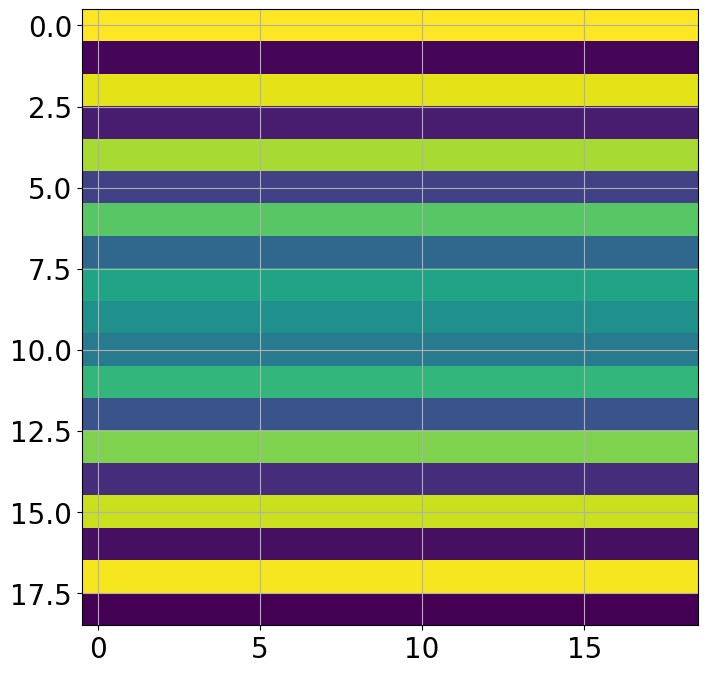

In [238]:
imshow(dc)

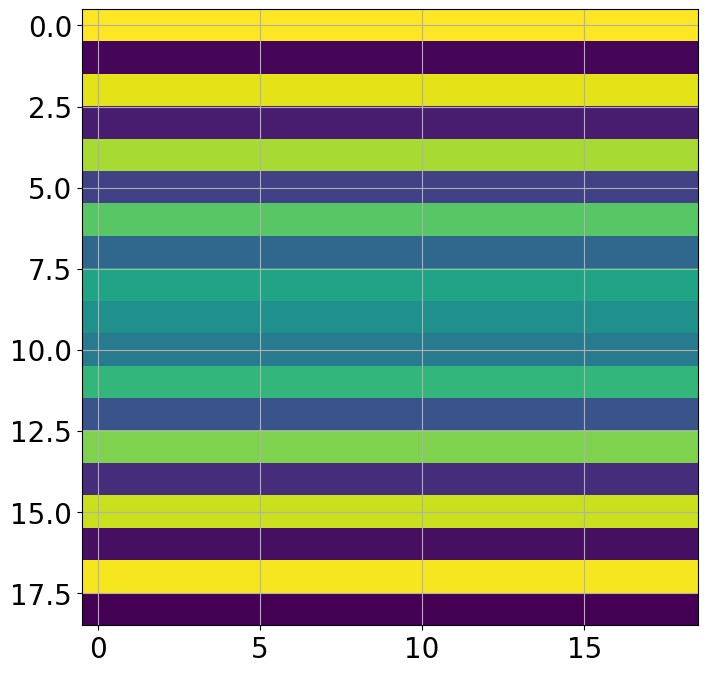

In [239]:
imshow(cos_vals)

In [250]:
sum(dc-cos_vals)

0.0

(2, 20, 722)

In [294]:
subR.W[0,0,:19*19]

array([-5.57064983e-03, -5.25139784e-03,  3.82961103e-03, -1.31036367e-03,
        9.71002066e-03,  8.75814076e-03,  8.90791349e-03,  9.94796880e-03,
       -9.95003802e-03,  7.05959669e-04, -9.62945230e-03,  7.93922916e-03,
        9.89852213e-03,  1.14170987e-04,  1.01844828e-03,  5.74019670e-03,
        5.56537742e-03, -1.35158379e-04, -2.96038965e-04,  7.17092214e-03,
       -6.69884285e-03,  3.75408610e-03,  3.83967182e-03, -1.66973338e-03,
        7.49491287e-03, -6.23744675e-03,  6.18617248e-03, -4.30660324e-03,
       -9.68274100e-03, -8.04901521e-03, -3.02789967e-03, -1.74855001e-03,
        3.91419959e-03,  8.34983835e-03, -7.96976118e-04, -7.40062746e-03,
        9.03545516e-03,  6.64053883e-03,  6.23773227e-03, -4.34505694e-03,
        2.34797988e-04, -8.70775740e-03, -2.51596575e-03, -7.93121891e-03,
       -2.23379408e-03, -3.35779777e-03,  4.42873340e-03,  1.35732452e-03,
        4.28652564e-04, -5.65075085e-03,  5.73465891e-03, -9.69732811e-03,
       -2.66299132e-04,  

In [299]:
subR.W.shape

(2, 20, 722)

In [300]:
RR[fname].W.shape

(193, 20, 722)

In [307]:
t,y=RR[fname].all_responses[0]
y=y.max(axis=1)  # optimize over theta
rk=y.transpose([1,2,3,0]) # channel, neuron, time,k
rk.shape  

(2, 20, 193, 40)

In [314]:
k_opt=repeat(RR[fname].k_mat[argmax(rk,axis=3)][:, :, :,newaxis],len(RR[fname].k_mat),axis=3)
k_opt.shape

(2, 20, 193, 40)

In [315]:
rk[(RR[fname].k_mat>k_opt)]=0

In [320]:
log16k=log(RR[fname].k_mat)/log(16)
log16k_opt=log(k_opt)/log(16)

LSVF=trapezoid(rk*(log16k-log16k_opt)**2,log16k)/trapezoid(rk,log16k,axis=3)
LSVF.shape

(2, 20, 193)

(-0.5, 18.5, 18.5, -0.5)

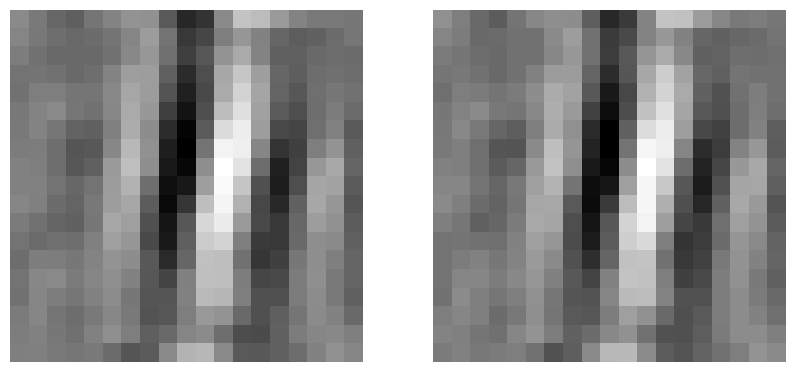

In [298]:
fname='sims-2025-03-13 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0.asdf'
subR=subResults[fname]

subplot(1,2,1)
imshow(subR.W[1,0,:19*19].reshape(19,19),cmap=cm.gray)
axis('off')

subplot(1,2,2)
imshow(subR.W[1,0,19*19:].reshape(19,19),cmap=cm.gray)
axis('off')

(-0.5, 18.5, 18.5, -0.5)

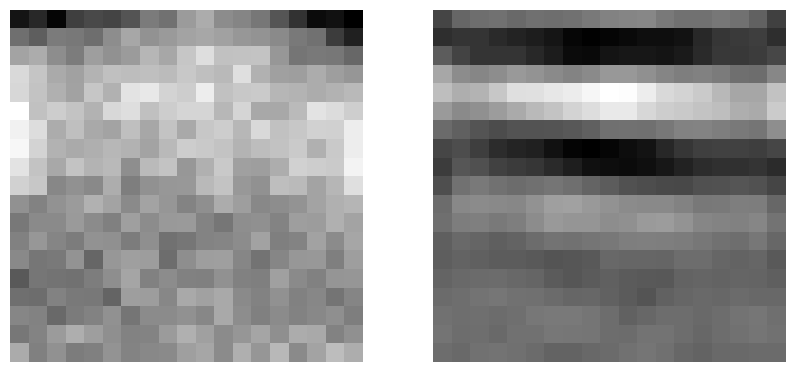

In [296]:
fname='sims-2025-03-13 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 8.0 mu_c 0.0.asdf'
subR=subResults[fname]

subplot(1,2,1)
imshow(subR.W[1,0,:19*19].reshape(19,19),cmap=cm.gray)
axis('off')

subplot(1,2,2)
imshow(subR.W[1,0,19*19:].reshape(19,19),cmap=cm.gray)
axis('off')

In [297]:
subR.W[1,0,:19*19]

array([-4.83534808e-02, -4.03858808e-02, -5.39636592e-02, -3.19559077e-02,
       -2.78836320e-02, -2.98342892e-02, -2.38441318e-02, -8.97396071e-03,
       -1.23421544e-02,  3.50109033e-03,  1.00031280e-02, -2.26650854e-03,
       -4.87331274e-03, -1.02439753e-02, -2.35656730e-02, -3.69496729e-02,
       -5.16809402e-02, -4.94059954e-02, -5.62431028e-02, -1.35875612e-02,
       -1.99753778e-02, -9.03306909e-03, -1.01553596e-02, -1.37524421e-02,
       -1.94776537e-03,  8.08173068e-03, -1.00040446e-04,  2.81883943e-03,
        6.84781436e-03,  7.86899861e-03,  5.75904284e-03,  1.93679358e-03,
        4.79110091e-04, -3.31650399e-03, -9.52006288e-03, -1.23696752e-02,
       -3.30488588e-02, -4.33555200e-02,  6.30154124e-03,  9.77450585e-03,
       -1.83779704e-03, -8.38164103e-03,  4.51413961e-03, -5.85945162e-04,
        3.25329803e-03,  1.35601894e-02,  8.01920965e-03,  1.98220372e-02,
        2.91709706e-02,  1.79384478e-02,  1.83806175e-02,  1.86792330e-02,
        1.92254688e-03, -

In [13]:
#t,w,number_of_channels,rf_diameter,theta,k_mat
responses=get_responses([subR.t[0],subR.t[-1]],subR.W,2,19,
              theta=linspace(0.0,180,24),
              k_mat=linspace(1,20,40)/19.0*pi)

In [14]:
responses=pn.get_responses([subR.t[0],subR.t[-1]],subR.W,2,19,
              theta=linspace(0.0,180,24),
              k_mat=linspace(1,20,40)/19.0*pi)

theta_mat=linspace(0.0,180,24)
k_mat=linspace(1,20,40)/19.0*pi

In [15]:
responses.shape  # kmat, theta_mat, channels, neurons, time

(40, 24, 2, 20, 2)

In [16]:
y=responses[:,:,1,0,-1]
y.shape

(40, 24)

In [17]:
idx=argmax(y)  # max across all angles and SF

In [18]:
i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
max_k_idx=j.ravel()[idx]
max_theta_idx=i.ravel()[idx]

max_k=k_mat[max_k_idx]
max_theta=theta_mat[max_theta_idx]
max_k,max_theta

(1.0514372173957742, 54.78260869565217)

Text(0.5, 0, 'SF [cyc/deg]')

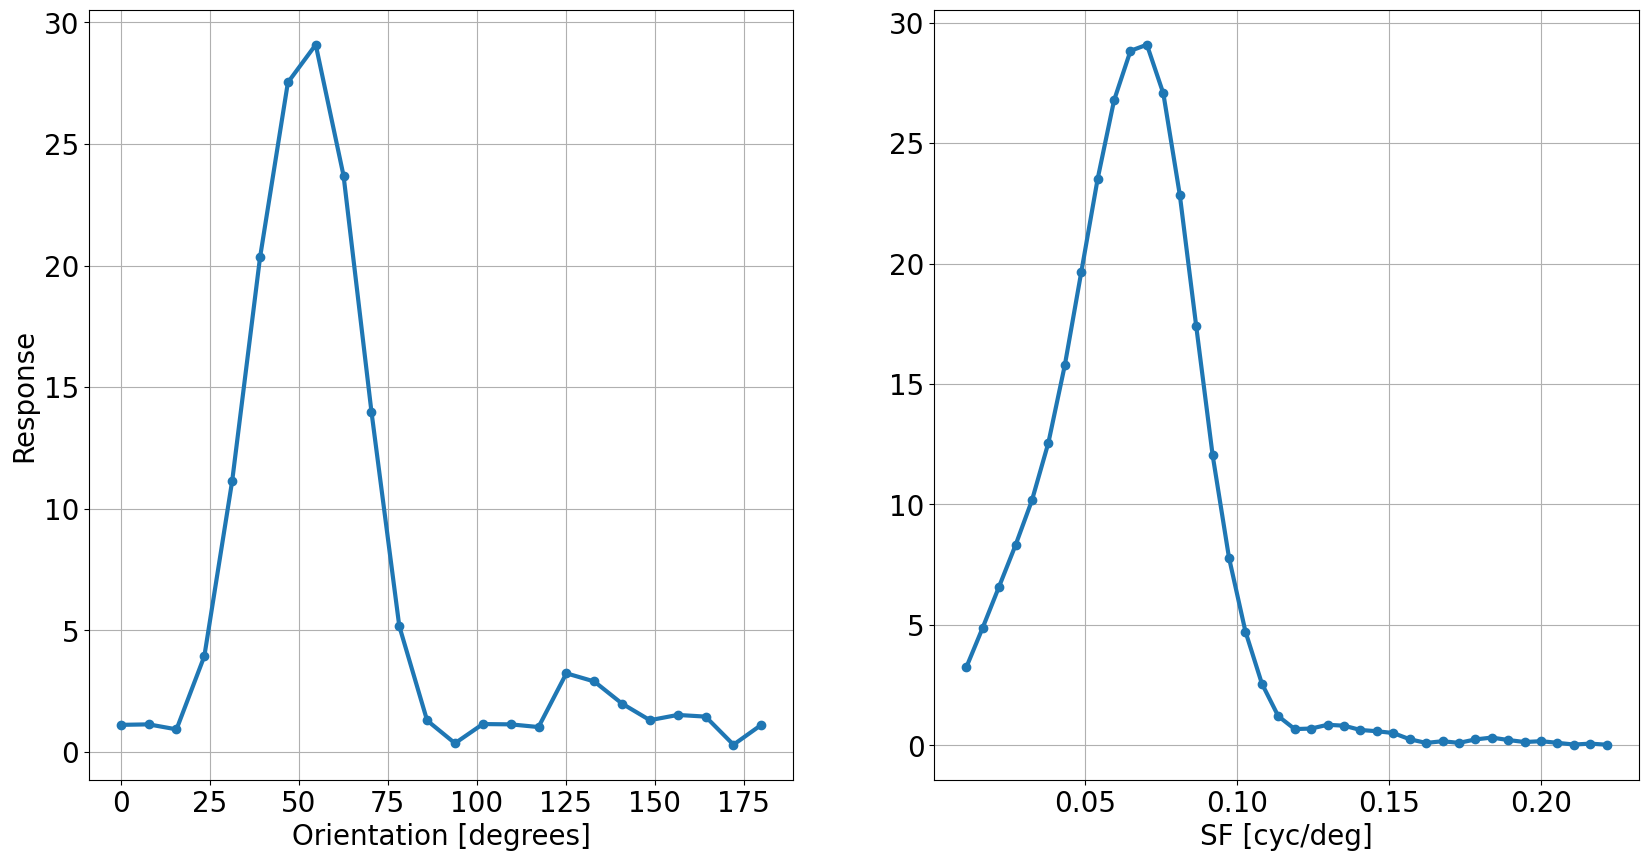

In [23]:
figure(figsize=(20,10))
subplot(1,2,1)
plot(theta_mat,y[max_k_idx,:],'-o')
xlabel('Orientation [degrees]')
ylabel('Response')
subplot(1,2,2)

deg_per_pixel=8/19

plot(k_mat/2/pi/19*8,y[:,max_theta_idx],'-o')
xlabel('SF [cyc/deg]')




0.15915494309189535


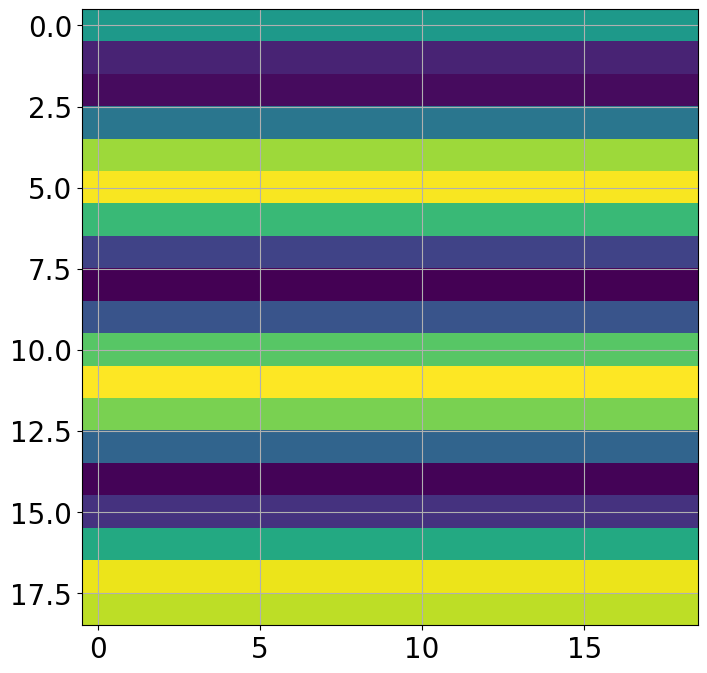

In [87]:
rf_diameter=19
rf_radius=rf_diameter/2
th=90
k=1

i,j=meshgrid(range(rf_diameter),range(rf_diameter))

a=3.14159265-th/180.0*3.14159265
kx=k*cos(a)
ky=k*sin(a)

cs=0.0
cc=0.0
wi=0
ds=sin(kx*(i-rf_radius)+ ky*(j-rf_radius))

print(k/(2*pi))

imshow(ds)

0.15915494309189535


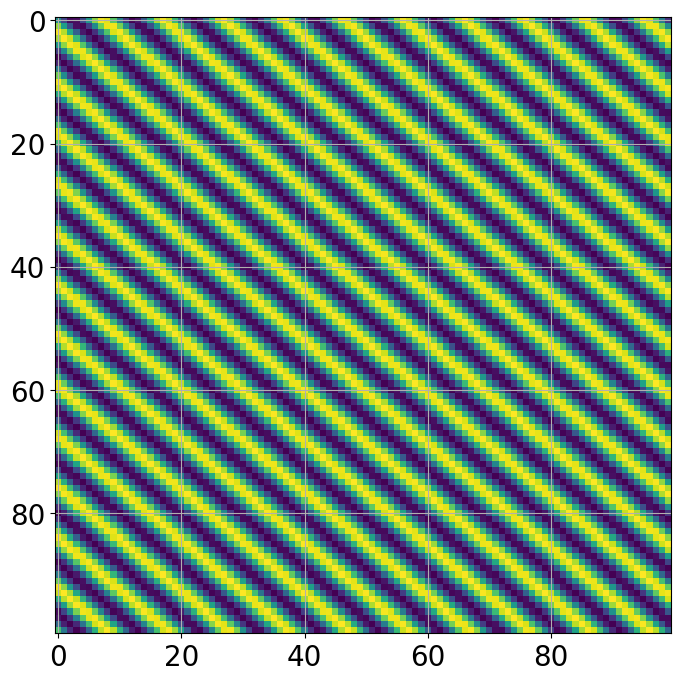

In [90]:
rf_diameter=19
rf_radius=rf_diameter/2
th=50
k=1

i,j=meshgrid(range(100),range(100))

a=3.14159265-th/180.0*3.14159265
kx=k*cos(a)
ky=k*sin(a)

cs=0.0
cc=0.0
wi=0
ds=sin(kx*i+ ky*j)

print(k/(2*pi))

imshow(ds)

In [ ]:
rf_diameter=19
rf_radius=rf_diameter/2
th=50
k=1

i,j=meshgrid(range(100),range(100))

a=3.14159265-th/180.0*3.14159265
kx=k*cos(a)
ky=k*sin(a)

cs=0.0
cc=0.0
wi=0
ds=sin(kx*i+ ky*j)

print(k/(2*pi))

imshow(ds)

In [93]:
im=[]
im_scale_shift=[1.0,0.0]

for th in tqdm(theta_mat):
    for k in k_mat:

        i,j=meshgrid(range(100),range(100))
        
        a=3.14159265-th/180.0*3.14159265
        kx=k*cos(a)
        ky=k*sin(a)
        
        cs=0.0
        cc=0.0
        wi=0
        ds=sin(kx*i+ ky*j)
    
        im.append(ds)

pi5.asdf_save_images({'im':im,'im_scale_shift':im_scale_shift},"gratings.asdf")

100%|██████████████████████████████████████████| 24/24 [00:00<00:00, 280.05it/s]


In [133]:
normal_gratings=pi5.filtered_images("gratings.asdf",
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=True,
                                    )
var=pi5.asdf_load_images(normal_gratings)

# blur_gratings=pi5.filtered_images("gratings.asdf",
#                                     {'type':'blur','size':6},
#                                     {'type':'norm'},
#                                     {'type':'dog','sd1':1,'sd2':3},   
#                                     verbose=True,
#                                     )
# var=pi5.asdf_load_images(blur_gratings)




im=[_*var['im_scale_shift'][0]+var['im_scale_shift'][1] for _ in var['im']]
len(im)

Using cache_images/cache_images_3086d59472ee2e43627e4b79f574edea.asdf from cache.

960

In [134]:
var_orig=pi5.asdf_load_images("gratings.asdf")
im_orig=[_*var_orig['im_scale_shift'][0]+var_orig['im_scale_shift'][1] for _ in var_orig['im']]

var=pi5.asdf_load_images(normal_gratings)
im=[_*var['im_scale_shift'][0]+var['im_scale_shift'][1] for _ in var['im']]


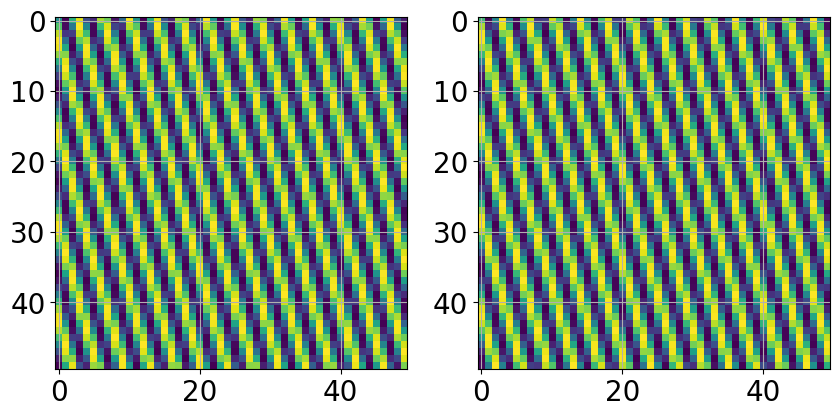

In [137]:
idx=100
subplot(1,2,1)
imshow(im_orig[idx][:50,:50])
subplot(1,2,2)
imshow(im[idx][:50,:50])


In [138]:
im_orig[idx][:50,:50]-im[idx][:50,:50]

array([[-0.52489256,  0.3833564 ,  0.41867727, ..., -0.44780258,
        -0.34921903,  0.54569329],
       [-0.61003808,  0.12054563,  0.57709274, ..., -0.20551099,
        -0.54111956,  0.35684287],
       [-0.55770781, -0.16944138,  0.60547849, ...,  0.08315328,
        -0.61109768,  0.08771685],
       ...,
       [ 0.61158533, -0.08661089, -0.58688701, ...,  0.17387096,
         0.55657486, -0.32829068],
       [ 0.54354687,  0.20222795, -0.59928704, ..., -0.1159939 ,
         0.61080572, -0.05352963],
       [ 0.35303706,  0.44552632, -0.47656604, ..., -0.37968623,
         0.52744959,  0.23332586]])

In [130]:
subR.W.shape

(2, 20, 722)

In [131]:
from scipy.signal import convolve2d

(52, 52)

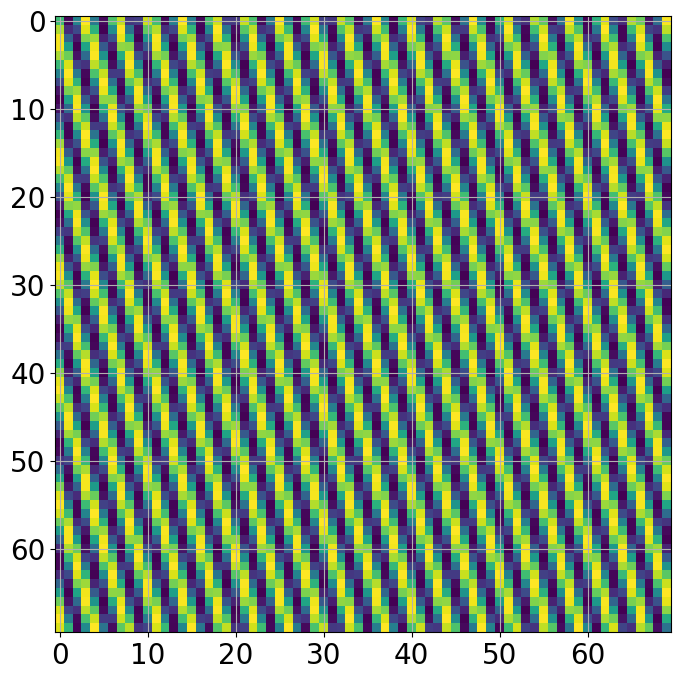

In [132]:
im1=im[100]
imshow(im1)
w1=subR.W[-1,0,:19*19].reshape(19,19)
w2=subR.W[-1,0,19*19:].reshape(19,19)

c1=convolve2d(im1,w1,mode='valid')
c2=convolve2d(im1,w1,mode='valid')
c1.shape

In [126]:
responses2=zeros((len(k_mat),len(theta_mat),2,subR.W.shape[1],1))  # kmat, theta_mat, channels, neurons, time
im_count=0
for thi,th in tqdm(enumerate(theta_mat),total=len(theta_mat)):
    for ki,k in enumerate(k_mat):

        im1=im[im_count]
        for ni in range(subR.W.shape[1]):
            w1=subR.W[-1,ni,:19*19].reshape(19,19)
            w2=subR.W[-1,ni,19*19:].reshape(19,19)
            
            c1=convolve2d(im1,w1,mode='valid')
            c2=convolve2d(im1,w2,mode='valid')
            
            responses2[ki,thi,0,ni,0]=c1.max()
            responses2[ki,thi,1,ni,0]=c2.max()

        im_count+=1

100%|███████████████████████████████████████████| 24/24 [00:41<00:00,  1.72s/it]


In [127]:
y=responses2[:,:,1,0,-1]
i,j=meshgrid(range(len(theta_mat)),range(len(k_mat)))
max_k_idx=j.ravel()[idx]
max_theta_idx=i.ravel()[idx]

max_k=k_mat[max_k_idx]
max_theta=theta_mat[max_theta_idx]
max_k,max_theta

(1.0514372173957742, 54.78260869565217)

Text(0.5, 0, 'SF [cyc/deg]')

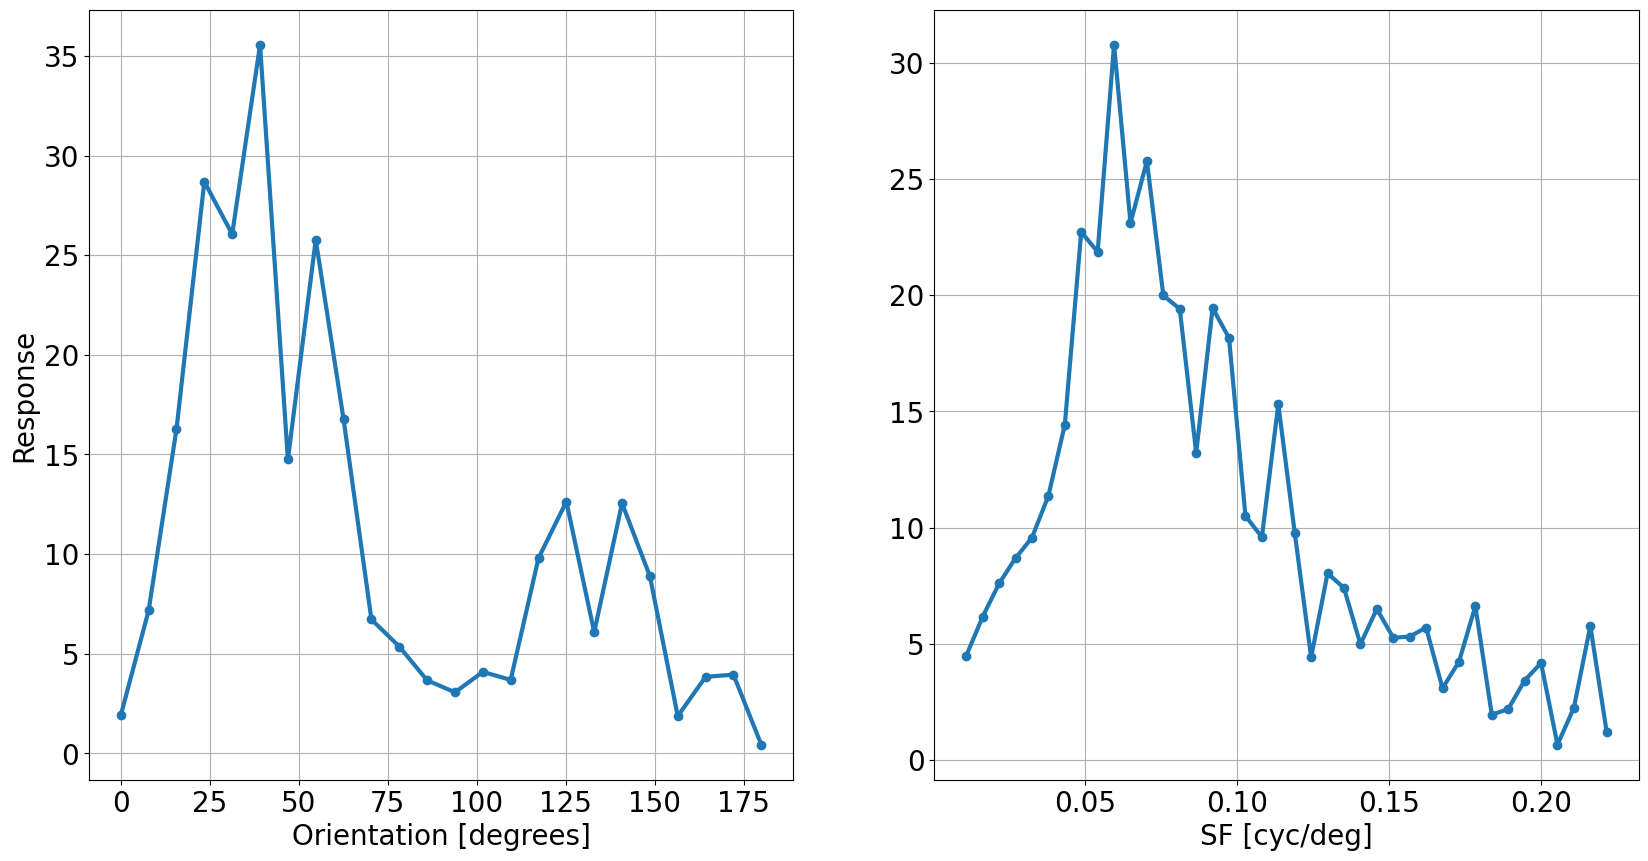

In [128]:
figure(figsize=(20,10))
subplot(1,2,1)
plot(theta_mat,y[max_k_idx,:],'-o')
xlabel('Orientation [degrees]')
ylabel('Response')
subplot(1,2,2)
plot(k_mat/2/pi/19*8,y[:,max_theta_idx],'-o')
xlabel('SF [cyc/deg]')


